# Interactive analysis of a saved sweep pair

**Workflow**:
1. Pick a pair (change `PAIR_IDX`)
2. Run the heatmap cells — aligned R², shuffle R², ΔR²
3. Run the `suggest_params(ctx)` cell — ranks parameters by three heuristics
4. Edit `FOCUS_PARAMS` based on what you saw and want to dig into
5. Run the parameter-specific plot cells

In [2]:
import sys, os
_HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)
from _analyze_helpers import load_pair, list_pairs, relabel_figure, label_cases, suggest_params, build_dual_r2_df
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Pick a pair

In [3]:
print("Available:")
for i, name in enumerate(list_pairs()):
    print(f"  {i}: {name}")
print(f"  moment_example/results/results.pt  (moment network — has σ)")

Available:
  0: pair_01_Mg_Mh_s90__Rs_Ms_s90
  1: pair_02_MBH_Mh_s61__SFR_Ms_s61
  2: pair_03_Ms_Mh_s90__SFR_Ms_s90
  3: pair_04_Rs_Ms_s61__Zs_Ms_s61
  moment_example/results/results.pt  (moment network — has σ)


In [4]:
PAIR_IDX = 1   # 0..3 for the sweep pairs
# Or load moment_example:
#   ctx = load_pair(results_path="moment_example/results/results.pt")
ctx = load_pair(pair_idx=PAIR_IDX)
ctx.summary()

Pair: MBH_Mh_s61  ×  SFR_Ms_s61
  observable_1 (A) = MBH_Mh_s61
  observable_2 (B) = SFR_Ms_s61
  8 cases:
    B_5.0_A_0.0           →  SFR=5.0, MBH=0.0
    B_2.5_A_0.0           →  SFR=2.5, MBH=0.0
    B_0.0_A_0.0           →  SFR=0.0, MBH=0.0
    B_0.0_A_2.5           →  SFR=0.0, MBH=2.5
    B_0.0_A_5.0           →  SFR=0.0, MBH=5.0
    B_1.0_A_1.0           →  SFR=1.0, MBH=1.0
    B_clean               →  SFR alone
    A_clean               →  MBH alone
  Focus params for plots: θ0, θ1, θ2, θ4, θ7, θ11 (adjust as needed)


## 2. Heatmaps — look here first

Read them to answer:
- Which parameters have any signal at all? (aligned R² > threshold in *some* case)
- Which parameters collapse under shuffling? (large negative ΔR²)
- Which parameters respond differently to obs1-shuffle vs obs2-shuffle?
  (asymmetric ΔR² between the two shuffle heatmaps)

### 2a. Aligned R² — the baseline (no shuffling)

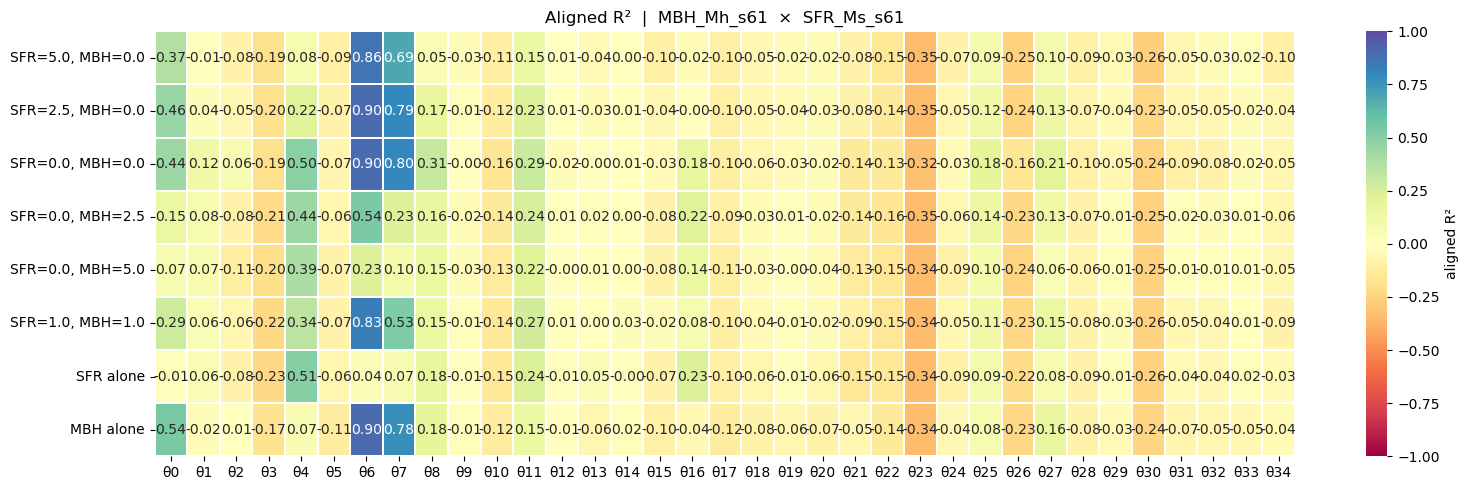

In [5]:
labels = label_cases(ctx, ctx.cases)
df = pd.DataFrame(ctx.r2_matrix, index=labels, columns=ctx.param_names)
plt.figure(figsize=(16, 5))
sns.heatmap(df, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap="Spectral",
            linewidths=0.2, cbar_kws={"label": "aligned R²"})
plt.title(f"Aligned R²  |  {ctx.obs1}  ×  {ctx.obs2}")
plt.tight_layout(); plt.show()

### 2b. Shuffled R² — obs2 shuffled (survives only if model reads obs1)

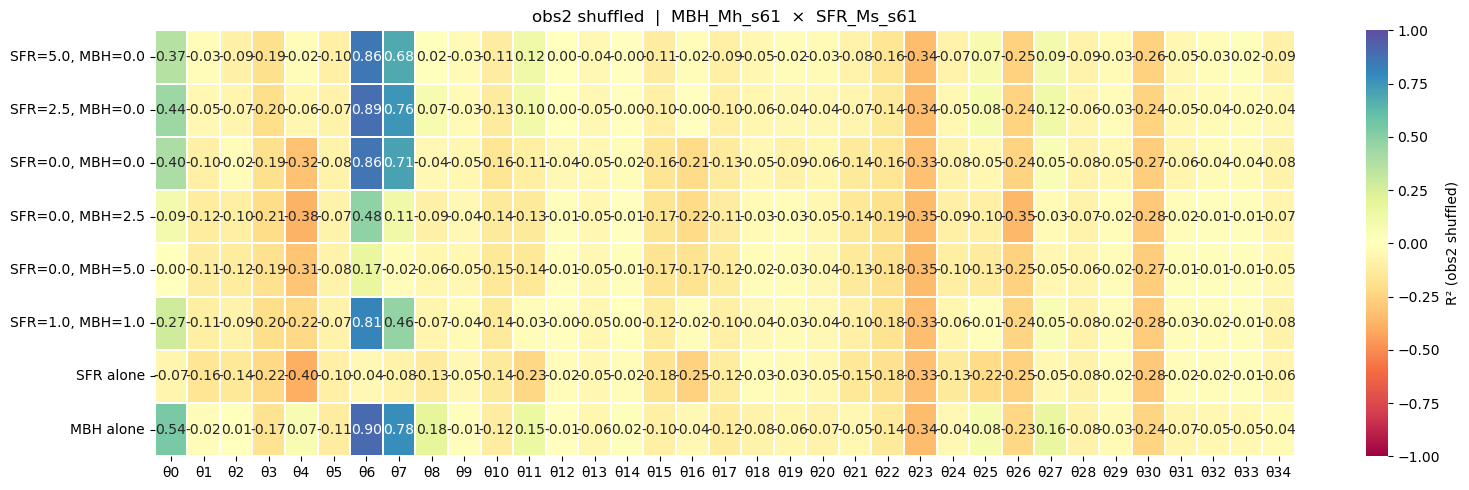

In [6]:
if ctx.r2_matrix_shifted_obs is not None:
    df = pd.DataFrame(ctx.r2_matrix_shifted_obs, index=labels, columns=ctx.param_names)
    plt.figure(figsize=(16, 5))
    sns.heatmap(df, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap="Spectral",
                linewidths=0.2, cbar_kws={"label": "R² (obs2 shuffled)"})
    plt.title(f"obs2 shuffled  |  {ctx.obs1}  ×  {ctx.obs2}")
    plt.tight_layout(); plt.show()

### 2c. Shuffled R² — obs1 shuffled (survives only if model reads obs2)

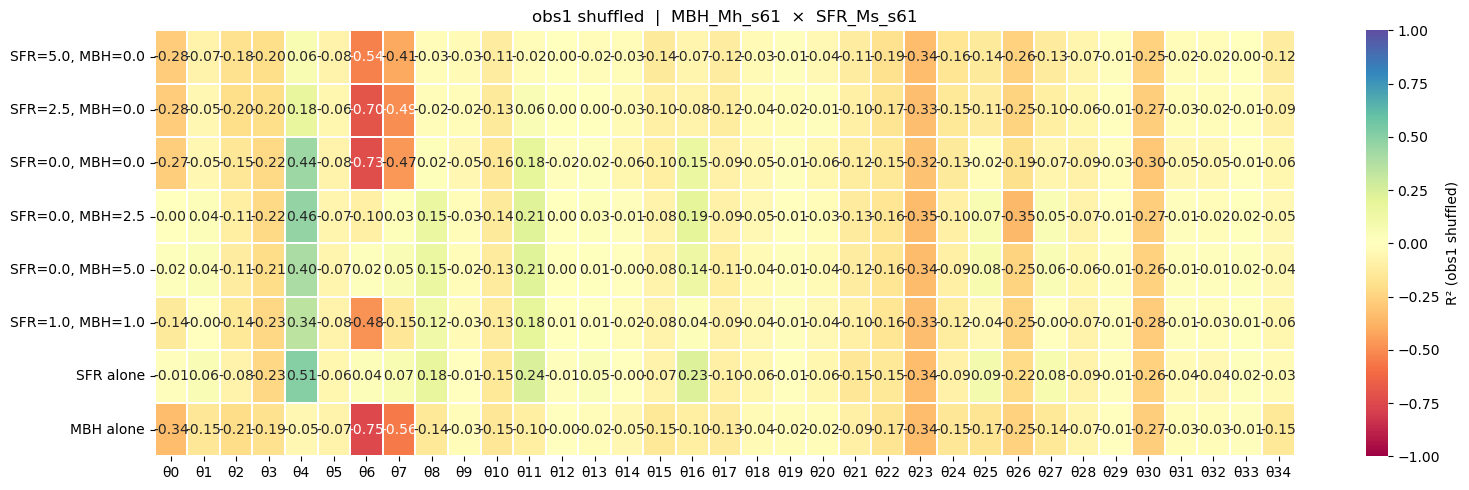

In [7]:
if ctx.r2_matrix_shifted_both is not None:
    df = pd.DataFrame(ctx.r2_matrix_shifted_both, index=labels, columns=ctx.param_names)
    plt.figure(figsize=(16, 5))
    sns.heatmap(df, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap="Spectral",
                linewidths=0.2, cbar_kws={"label": "R² (obs1 shuffled)"})
    plt.title(f"obs1 shuffled  |  {ctx.obs1}  ×  {ctx.obs2}")
    plt.tight_layout(); plt.show()

### 2d. ΔR² — obs2 shuffled (negative = information lost)

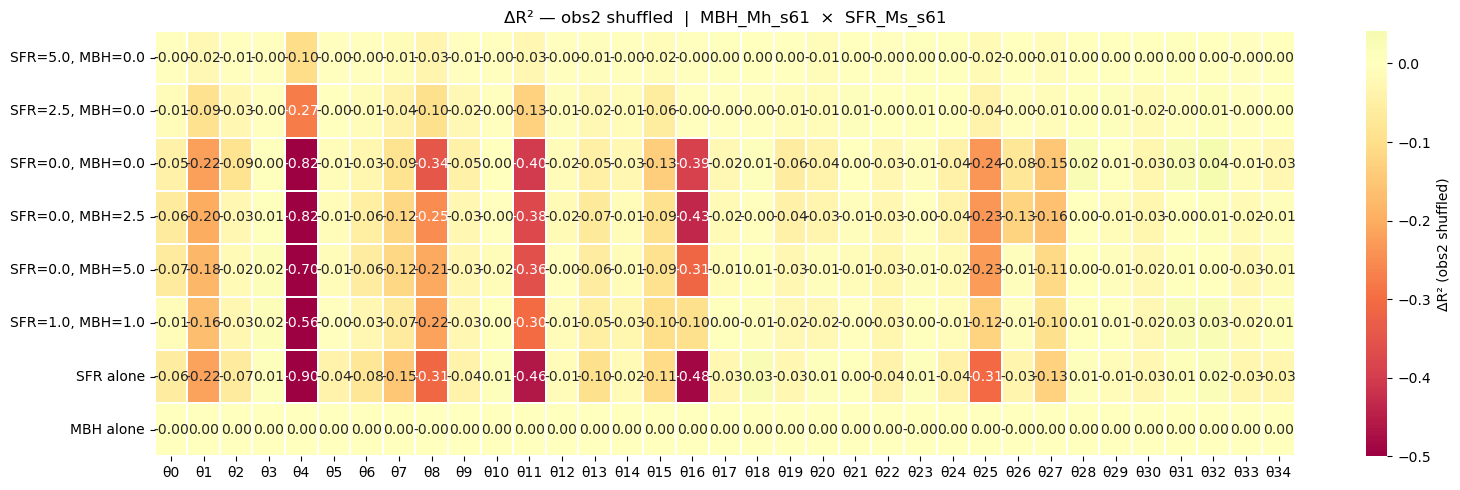

In [8]:
if ctx.r2_matrix_shifted_obs is not None:
    delta = ctx.r2_matrix_shifted_obs - ctx.r2_matrix
    df = pd.DataFrame(delta, index=labels, columns=ctx.param_names)
    plt.figure(figsize=(16, 5))
    sns.heatmap(df, center=0.0, vmin=-0.5, annot=True, fmt=".2f", cmap="Spectral",
                linewidths=0.3, cbar_kws={"label": "ΔR² (obs2 shuffled)"})
    plt.title(f"ΔR² — obs2 shuffled  |  {ctx.obs1}  ×  {ctx.obs2}")
    plt.tight_layout(); plt.show()

### 2e. ΔR² — obs1 shuffled

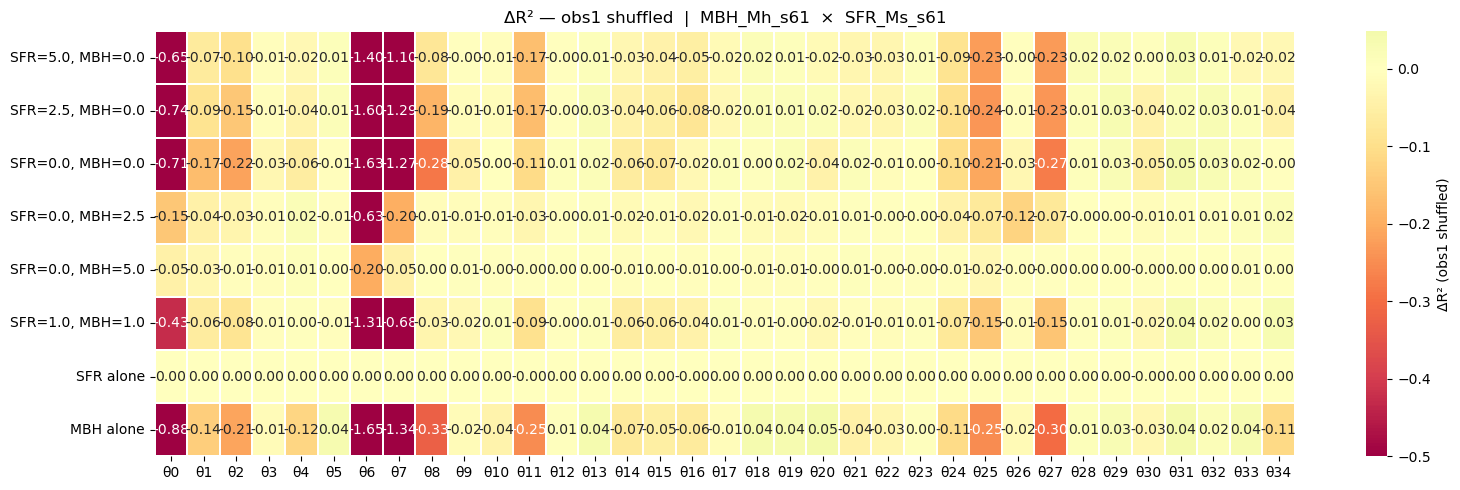

In [9]:
if ctx.r2_matrix_shifted_both is not None:
    delta = ctx.r2_matrix_shifted_both - ctx.r2_matrix
    df = pd.DataFrame(delta, index=labels, columns=ctx.param_names)
    plt.figure(figsize=(16, 5))
    sns.heatmap(df, center=0.0, vmin=-0.5, annot=True, fmt=".2f", cmap="Spectral",
                linewidths=0.3, cbar_kws={"label": "ΔR² (obs1 shuffled)"})
    plt.title(f"ΔR² — obs1 shuffled  |  {ctx.obs1}  ×  {ctx.obs2}")
    plt.tight_layout(); plt.show()

## 3. Ranked parameter suggestions

Three rankings:
  - **well-constrained**: high aligned R² in any case (worth looking at at all)
  - **information-sharing**: R² drops sharply under best shuffle (obs matters)
  - **shuffle-asymmetric**: obs1-shuffle and obs2-shuffle disagree most (differential contribution)

The `union` list combines all three. Paste it (or a subset) into `FOCUS_PARAMS` below.

In [10]:
suggestions = suggest_params(ctx, top_n=6, min_aligned_r2=0.1)

Suggested parameters (top 6):
  well-constrained   (highest max-case aligned R²):
    θ6      +0.90
    θ7      +0.80
    θ0      +0.54
    θ4      +0.51
    θ8      +0.31
    θ11     +0.29
  information-sharing (biggest R² drop under best shuffle):
    θ6      ΔR² = -1.65
    θ7      ΔR² = -1.34
    θ4      ΔR² = -0.90
    θ0      ΔR² = -0.88
    θ16     ΔR² = -0.48
    θ11     ΔR² = -0.46
  shuffle-asymmetric  (obs1-shuf vs obs2-shuf disagree most):
    θ6      |Δ diff| = +1.65
    θ7      |Δ diff| = +1.34
    θ4      |Δ diff| = +0.90
    θ0      |Δ diff| = +0.88
    θ16     |Δ diff| = +0.48
    θ11     |Δ diff| = +0.46

  Union of the above (paste into FOCUS_PARAMS):
    FOCUS_PARAMS = ['θ6', 'θ7', 'θ0', 'θ4', 'θ8', 'θ11', 'θ16']


## 4. Set focus params — the ones you want deep plots for

Either paste from `suggestions['union']` above, or handpick from the heatmaps.

In [11]:
FOCUS_PARAMS = [1,4,7,11,16,34] #suggestions["union"]     # or e.g. ["θ4", "θ7", "θ11"]
print(f"Will make deep plots for: {FOCUS_PARAMS}")

Will make deep plots for: [1, 4, 7, 11, 16, 34]


## 5. Deep plots — for each param in FOCUS_PARAMS

### 5a. Predictions overlaid across cases (per parameter)

/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/src/plots.py:1934: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/_analyze_helpers.py:337: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


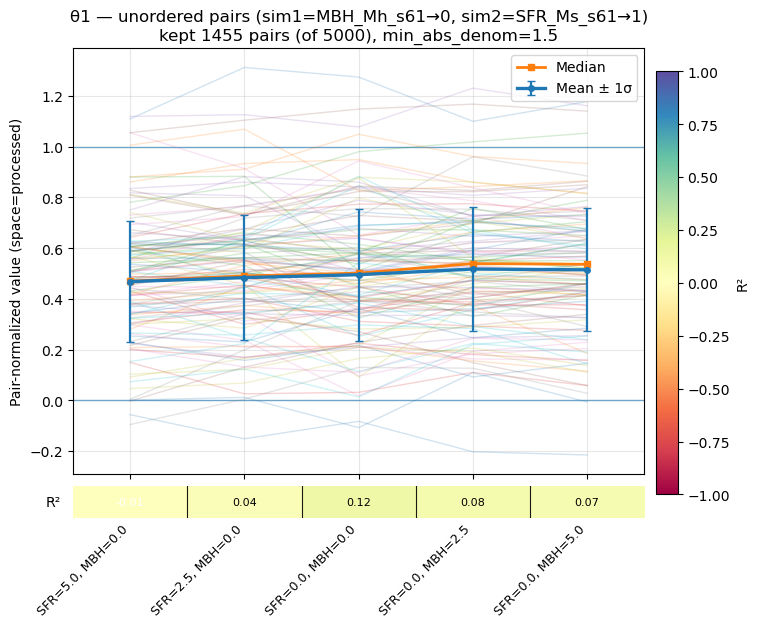

/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/src/plots.py:1934: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/_analyze_helpers.py:337: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


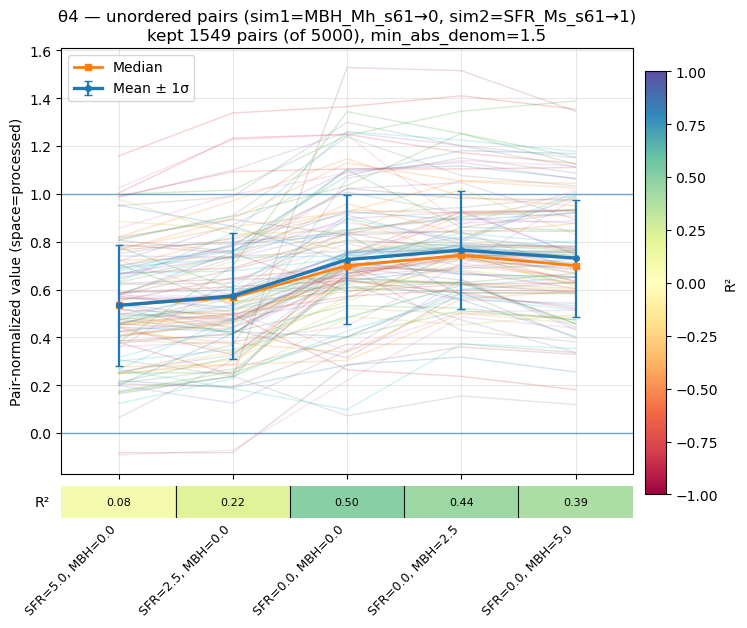

/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/src/plots.py:1934: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/_analyze_helpers.py:337: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


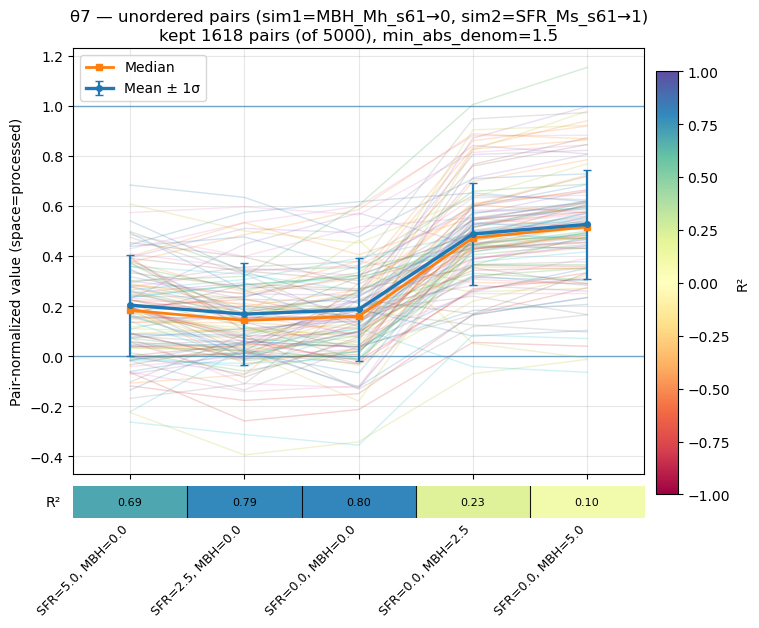

/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/src/plots.py:1934: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/_analyze_helpers.py:337: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


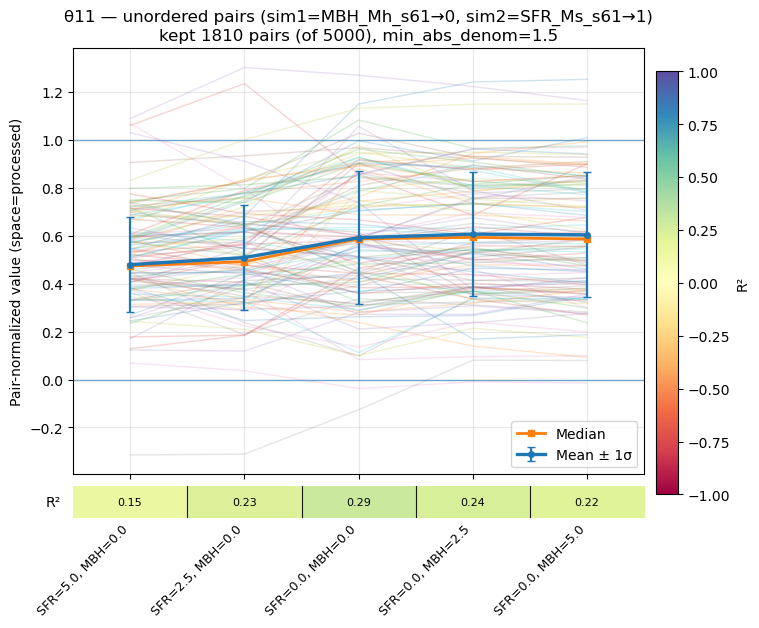

/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/src/plots.py:1934: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/_analyze_helpers.py:337: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


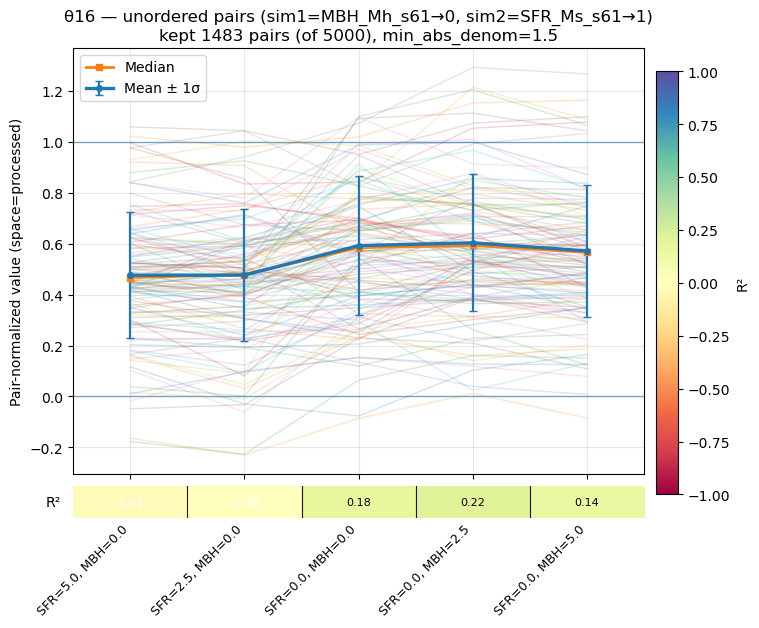

/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/src/plots.py:1934: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/_analyze_helpers.py:337: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


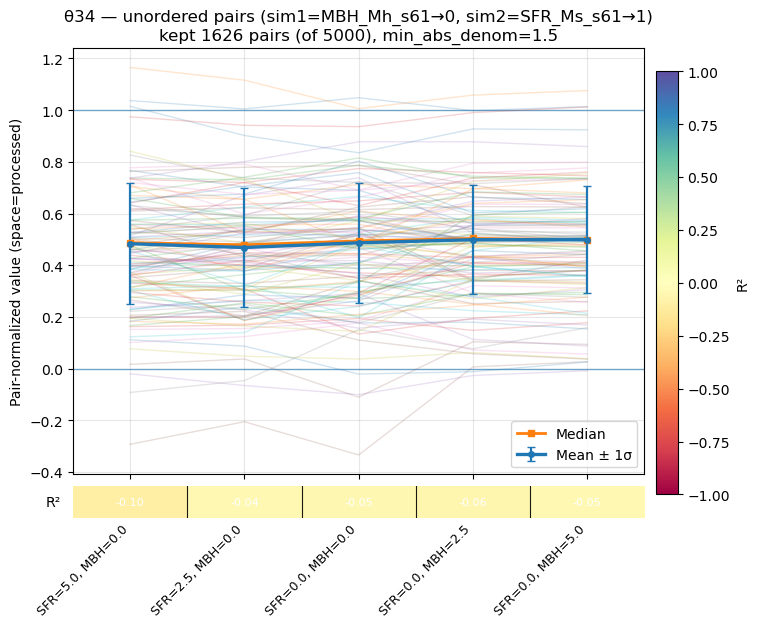

In [12]:
for p in FOCUS_PARAMS:
    ctx.plots.plot_param_unordered_pair_normalized_values(p, space = "processed", min_abs_denom=1.5,)
    relabel_figure(ctx)
    plt.show()

### 5b. Dual-curve plot (aligned + both shuffle modes)

In [13]:
if ctx.r2_matrix_shifted_obs is not None and ctx.r2_matrix_shifted_both is not None:
    dual_r2_df = build_dual_r2_df(ctx)   # includes real ±σ from 10-perm averaging
    for p in FOCUS_PARAMS:
        try:
            ctx.plots.plot_param_curve_dual(dual_r2_df, p, figsize=(8, 5), show_band=True)
            relabel_figure(ctx)
            plt.show()
        except Exception as e:
            print(f"[warn] {p}: {e}")

[warn] 1: No rows for param 1
[warn] 4: No rows for param 4
[warn] 7: No rows for param 7
[warn] 11: No rows for param 11
[warn] 16: No rows for param 16
[warn] 34: No rows for param 34


### 5c. Bias-progression overlay (per parameter)
For each param, overlays (pred - true) vs true bias curves across cases sorted
along the dual clean→asym→both-clean→asym→clean sequence.

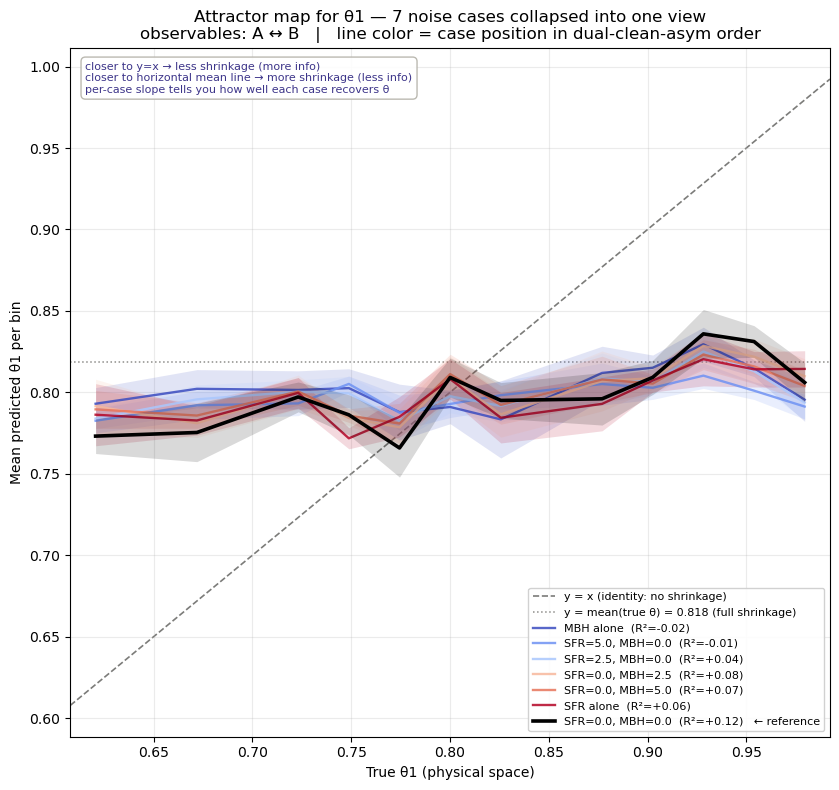

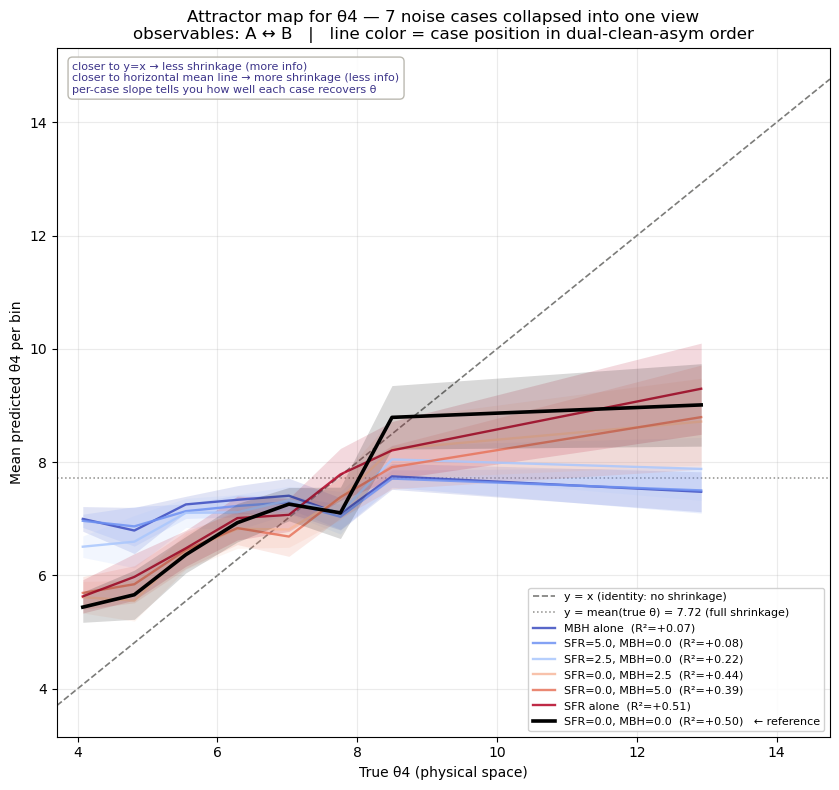

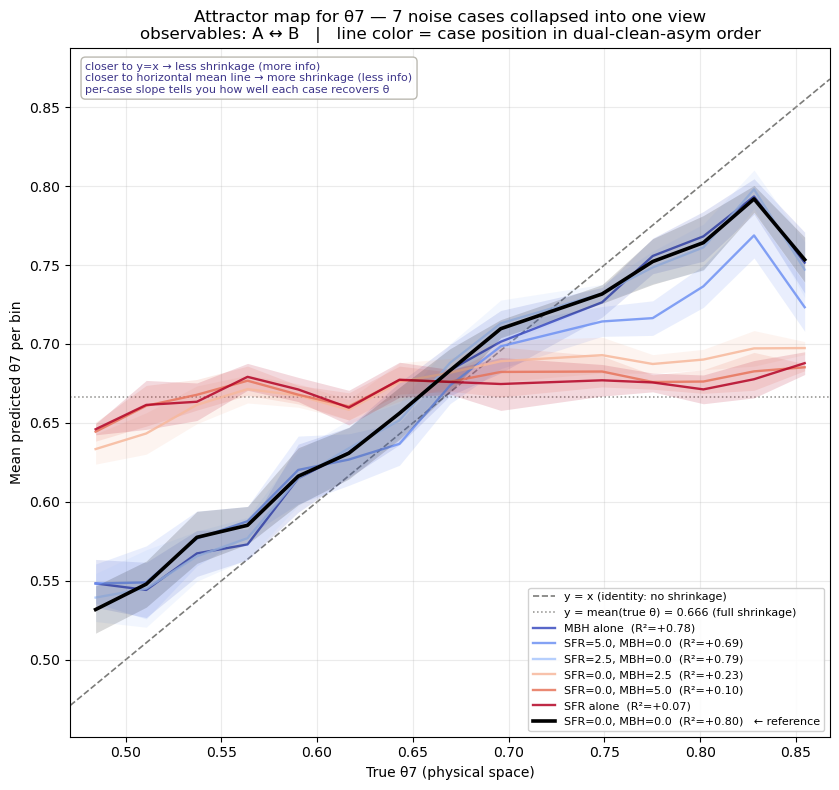

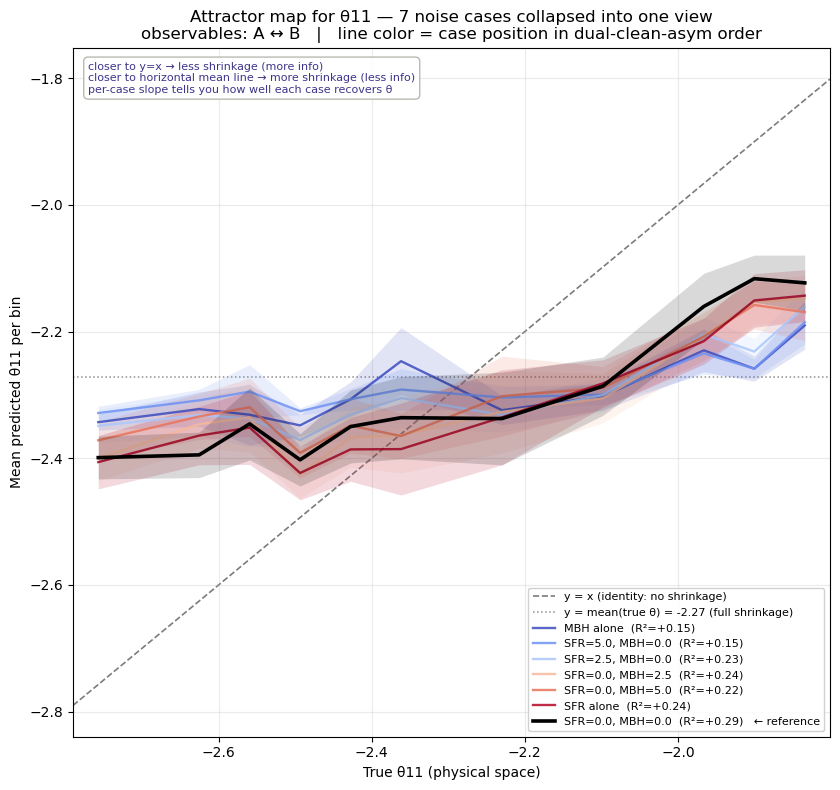

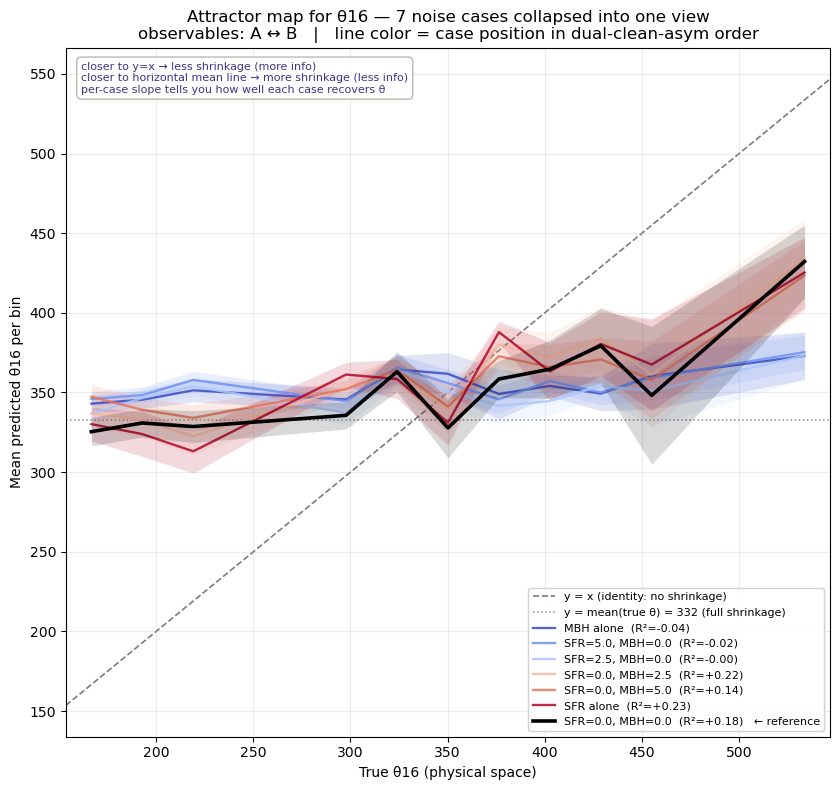

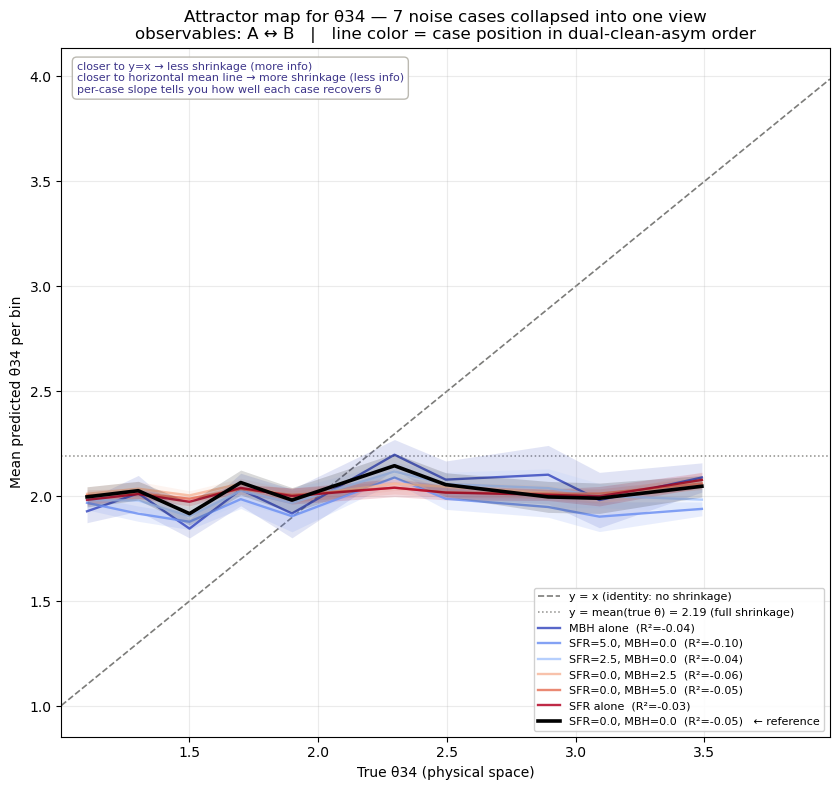

In [14]:
for p in FOCUS_PARAMS:
    try:
        fig, stats = ctx.plots.plot_prediction_attractor_map(param=p, )
        relabel_figure(ctx)
        plt.show()
    except Exception as e:
        print(f"[warn] plot_bias_progression_overlay({p}): {e}")

### 5d. Pair-normalized values (one param, one mode)
Shows p_norm = (pred - t0) / (t1 - t0) where t0/t1 are the pair endpoint truths.
`mode="obs2_vs_truth"` shuffles observable_1; `normalize_endpoints="obs1_to_obs2"`
maps obs1's truth → 0 and obs2's truth → 1 on the y-axis.

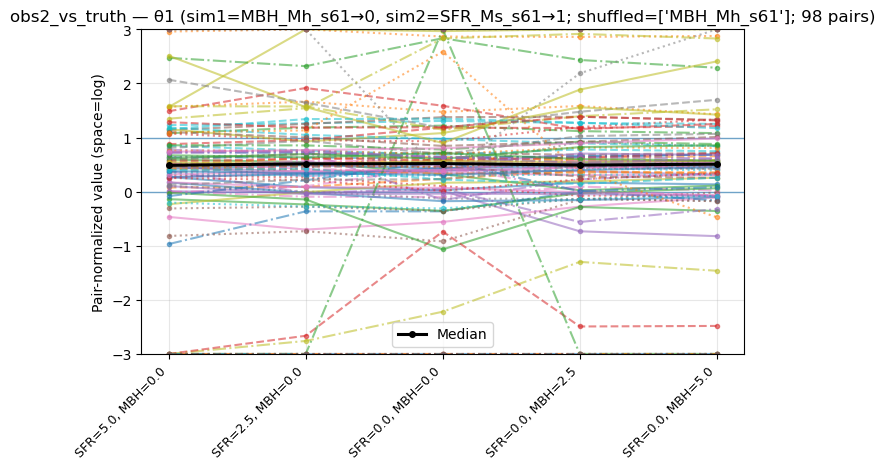

In [15]:
PAIR_PARAM = FOCUS_PARAMS[0] if FOCUS_PARAMS else "θ4"
try:
    ctx.plots.plot_param_pair_normalized_values(
        PAIR_PARAM,
        space="log",
        mode="obs2_vs_truth",
        normalize_endpoints="obs1_to_obs2",
    )
    relabel_figure(ctx)
    plt.show()
except Exception as e:
    print(f"[warn] plot_param_pair_normalized_values({PAIR_PARAM}): {e}")

### 5e. Side-by-side pair-normalized shuffle scatter (obs1 vs obs2 modes)
Two panels: obs1_vs_truth and obs2_vs_truth for the same param.
Reveals which observable pulls predictions off-line under each shuffle.

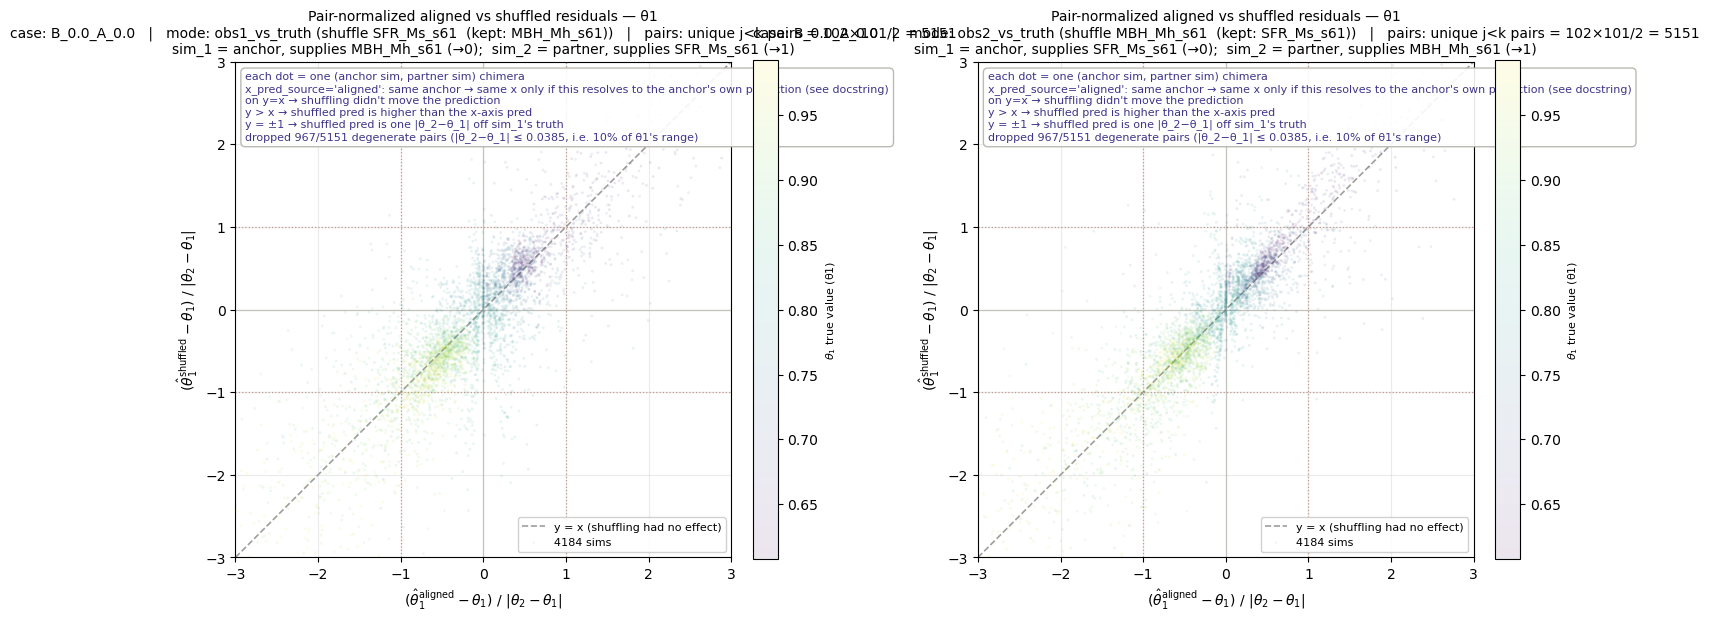

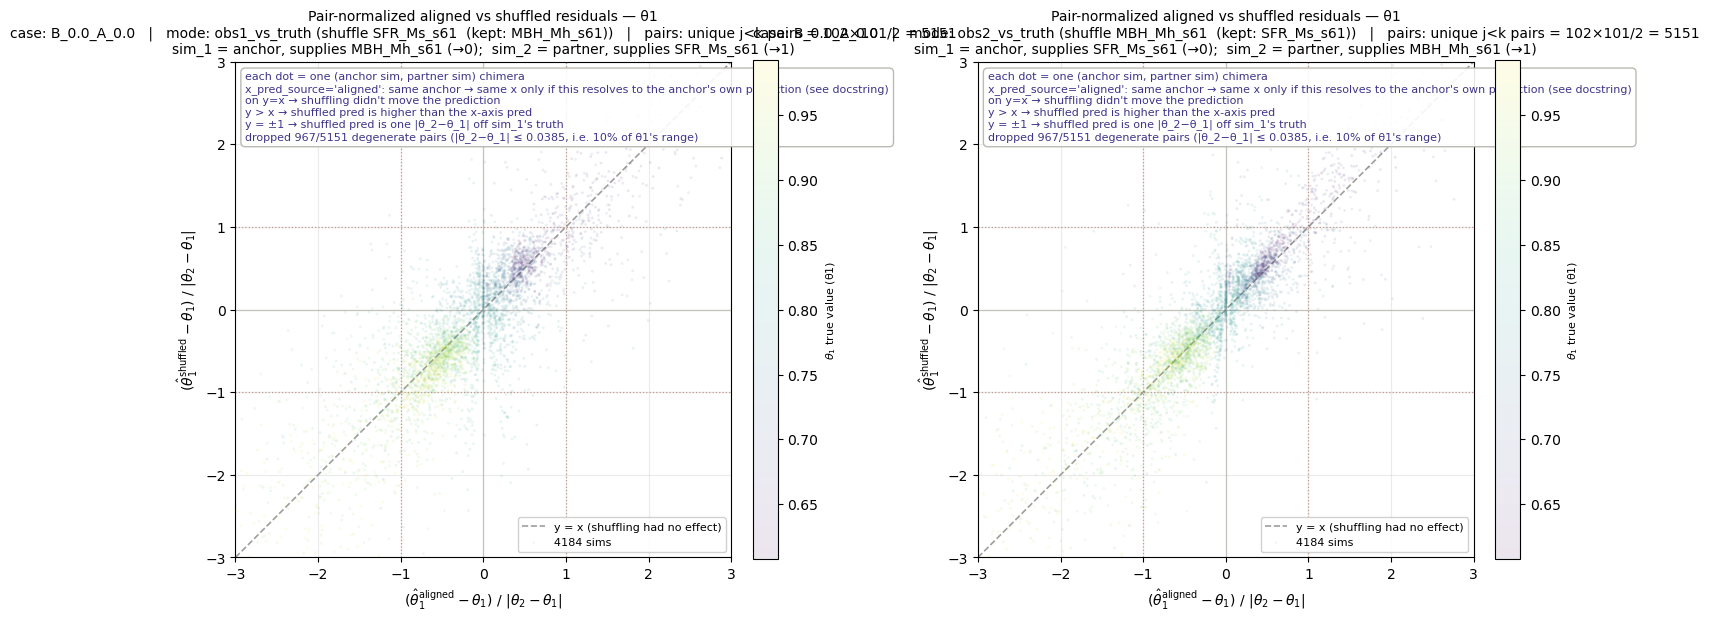

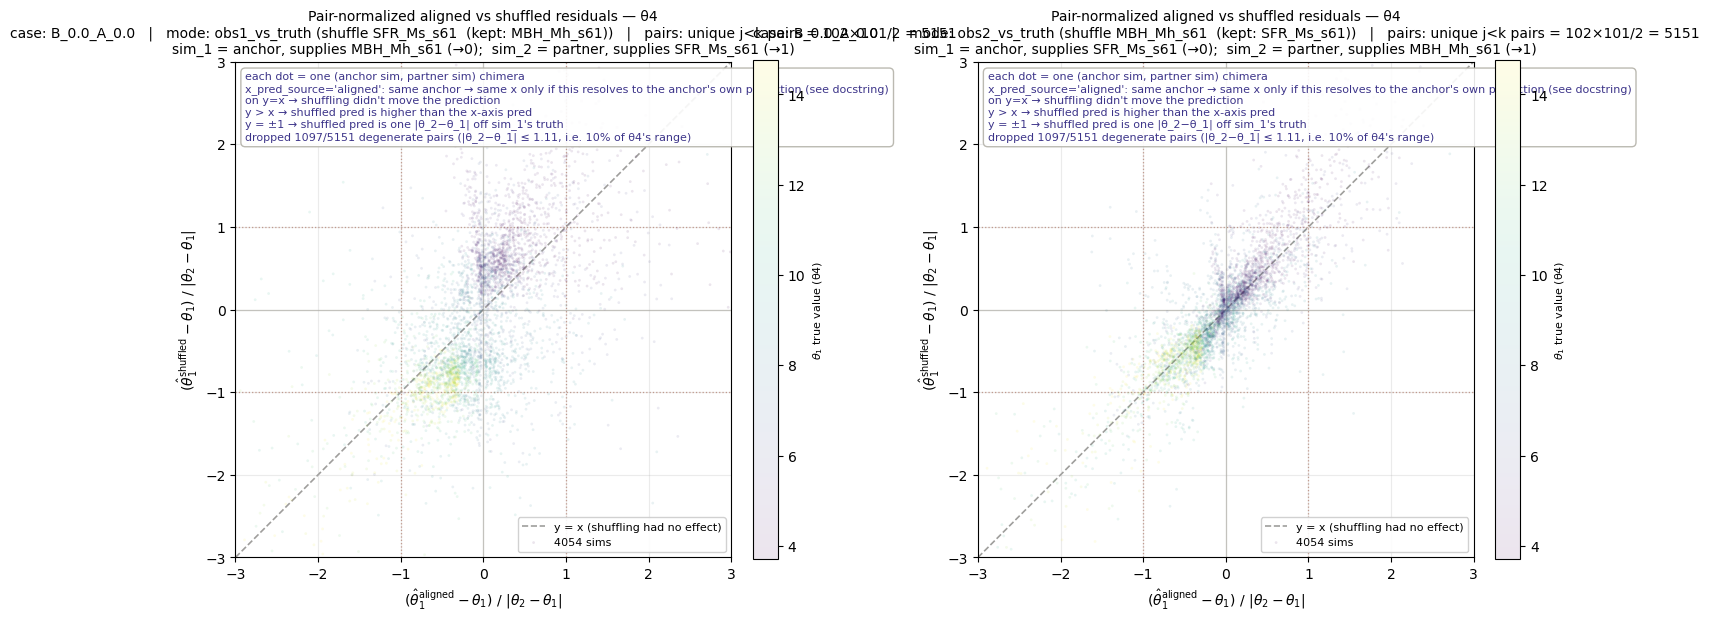

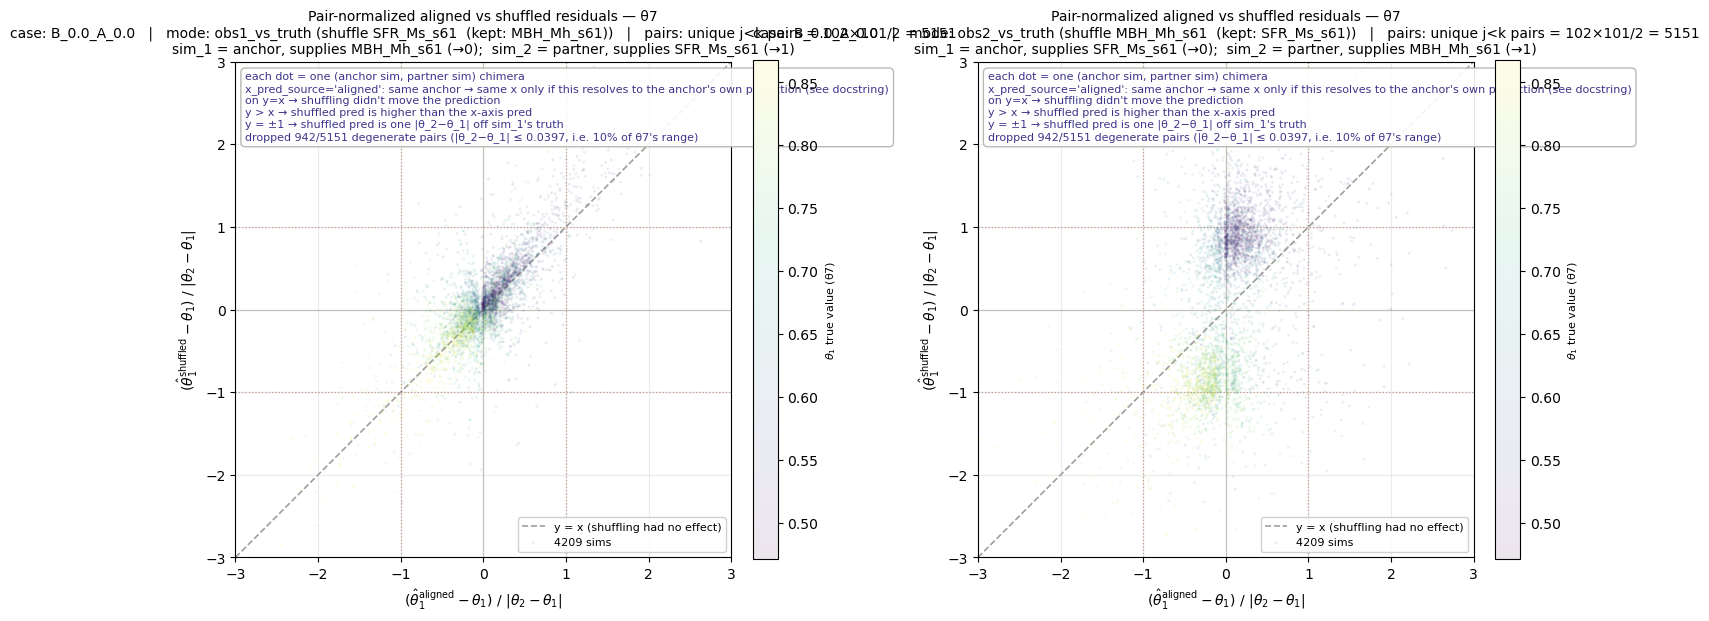

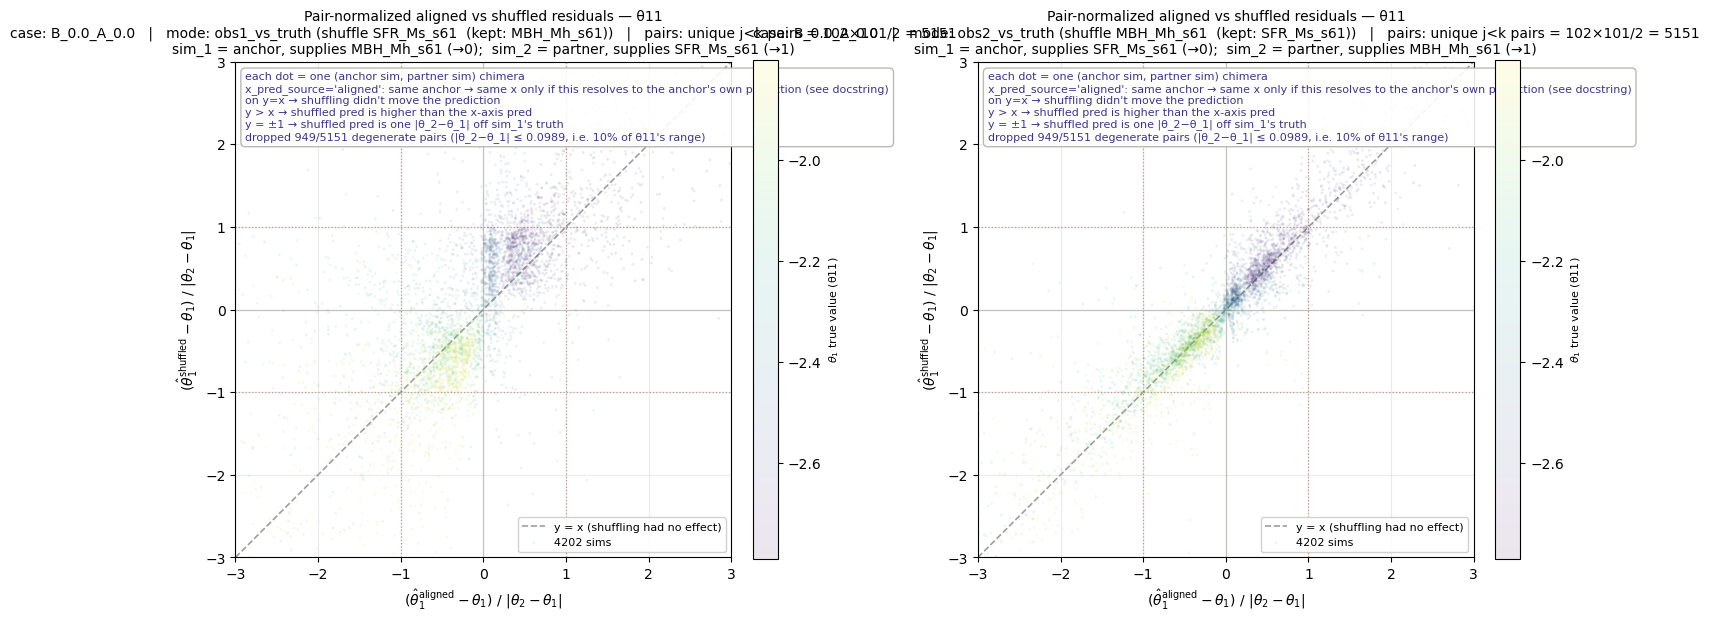

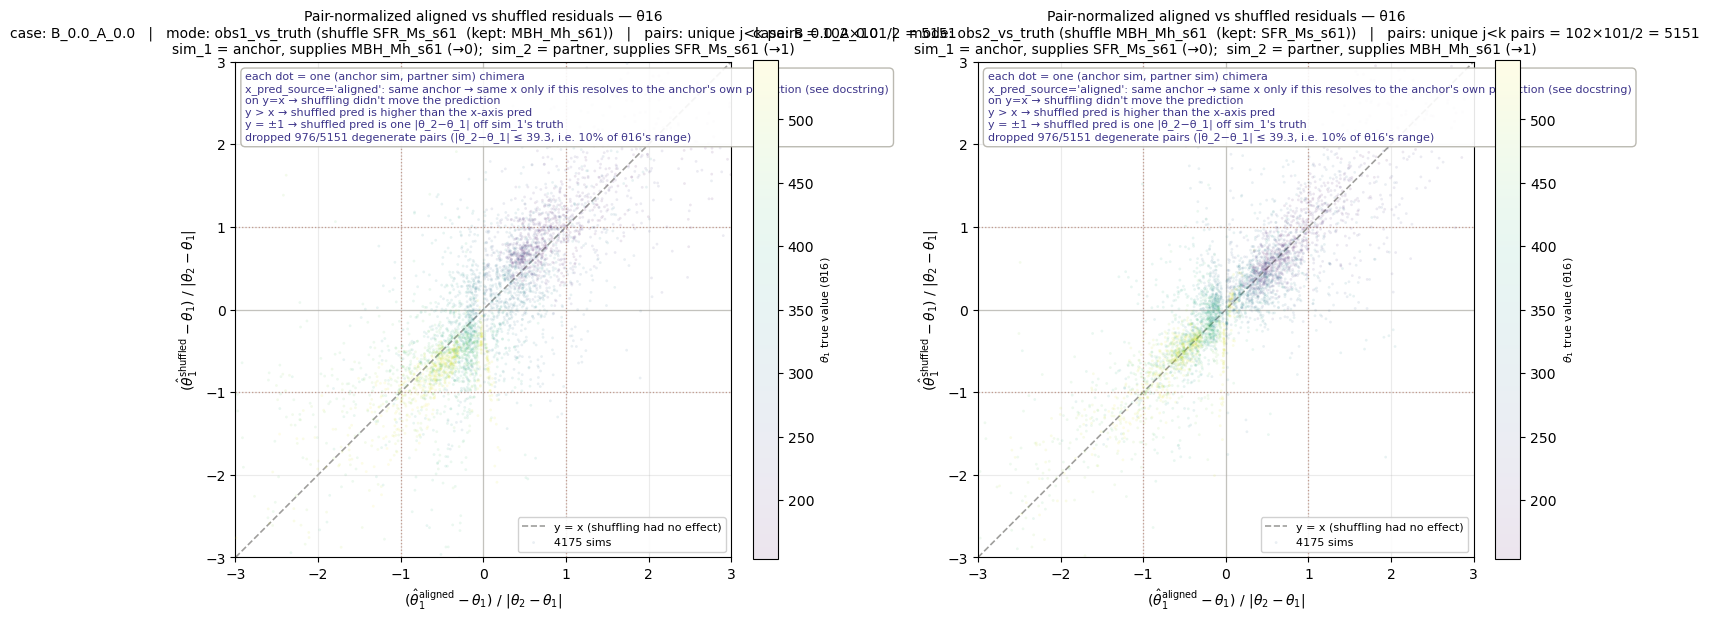

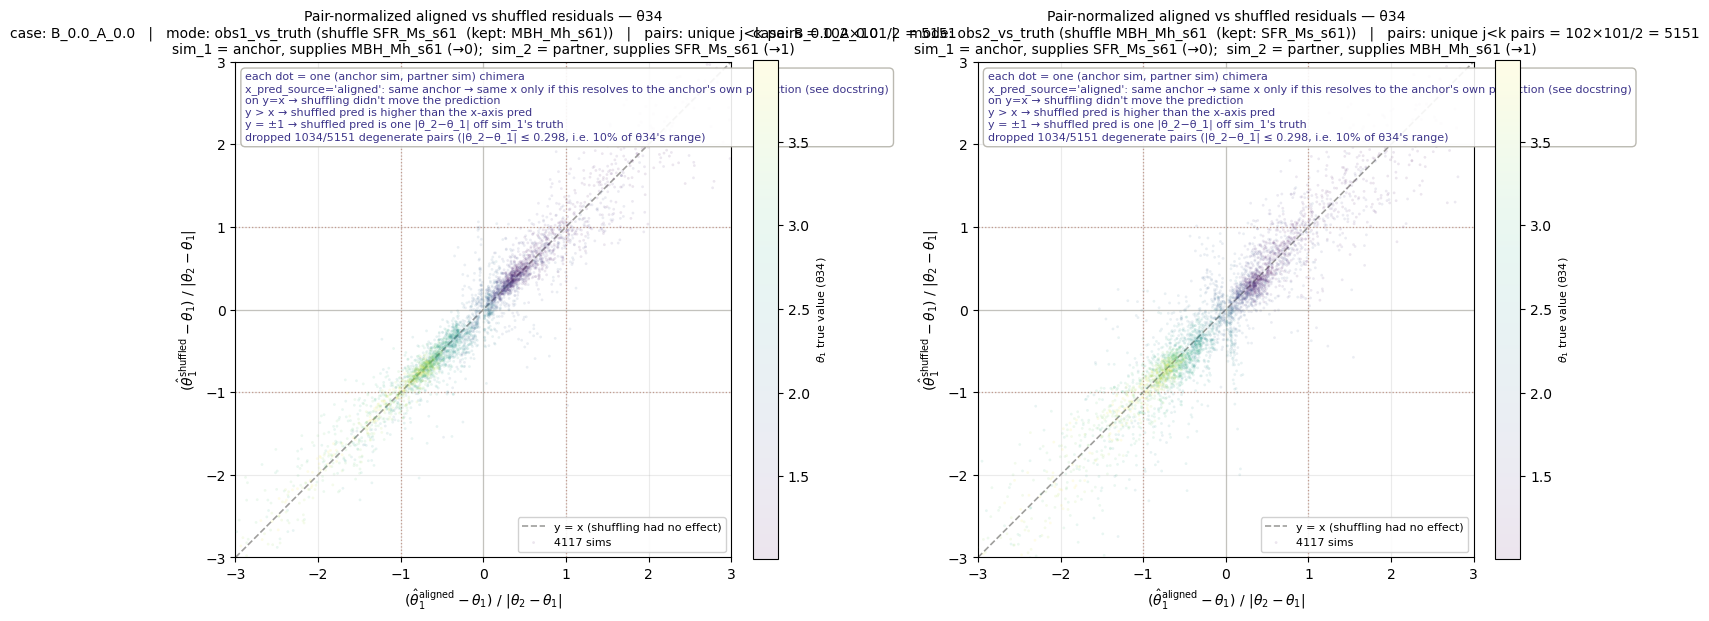

In [16]:
def _side_by_side_shuffle_scatter(param):
    fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
    _ax_iter = iter(axes)
    _orig_subplots = plt.subplots
    plt.subplots = lambda *a, **k: (fig, next(_ax_iter))
    stats_obs1 = stats_obs2 = None
    try:
        _, stats_obs1 = ctx.plots.plot_pair_normalized_shuffle_scatter(
            param=param, n_pairs="all", case=None,
            mode="obs1_vs_truth", color_by_theta1=True,
        )
        _, stats_obs2 = ctx.plots.plot_pair_normalized_shuffle_scatter(
            param=param, n_pairs="all", case=None,
            mode="obs2_vs_truth", color_by_theta1=True,
        )
    finally:
        plt.subplots = _orig_subplots
    fig.tight_layout()
    return fig, stats_obs1, stats_obs2

SHUFFLE_SCATTER_PARAM = FOCUS_PARAMS[0] if FOCUS_PARAMS else "θ4"
try:
    fig, s1, s2 = _side_by_side_shuffle_scatter(SHUFFLE_SCATTER_PARAM)
    #relabel_figure(ctx, fig)
    plt.show()
except Exception as e:
    print(f"[warn] shuffle_scatter({SHUFFLE_SCATTER_PARAM}): {e}")

# Loop across FOCUS_PARAMS if you want one per param — uncomment:
for p in FOCUS_PARAMS:
    fig, s1, s2 = _side_by_side_shuffle_scatter(p)
    #relabel_figure(ctx, fig)
    plt.show()

## 6. Moment-network plots (only if this pair has a variance head)

`has_variance` is True only for `moment_example`. Load it via:
  `ctx = load_pair(results_path="moment_example/results/results.pt")`

In [17]:
if ctx.has_variance:
    for p in FOCUS_PARAMS:
        ctx.plots.plot_marginal_posterior_grid(p, cases=ctx.cases, n_sims=6, seed=42,
                                                space="log_partial")
        relabel_figure(ctx)
        plt.show()
    ctx.plots.plot_sigma_by_case_bars(FOCUS_PARAMS, ctx.cases, space="log_partial")
    relabel_figure(ctx)
    plt.show()
    ctx.plots.plot_pull_distribution(ctx.cases, space="normalized", params=FOCUS_PARAMS)
    plt.show()
else:
    print(f"Pair '{ctx.pair_dir}' has no variance head.")
    print("Reload with:  ctx = load_pair(results_path='moment_example/results/results.pt')")

Pair '/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/pair_02_MBH_Mh_s61__SFR_Ms_s61/results' has no variance head.
Reload with:  ctx = load_pair(results_path='moment_example/results/results.pt')


## 7. Custom cell — one sim, one param (moment example only)

In [18]:
if ctx.has_variance and FOCUS_PARAMS:
    ctx.plots.plot_marginal_posterior_1d(FOCUS_PARAMS[0], sim_idx=3,
                                          cases=ctx.cases, space="log_partial")
    relabel_figure(ctx)
    plt.show()